# Práctica: Predicción de Tipo de Vino con Naive Bayes

**Objetivo:** Clasificar tipos de vino basados en sus propiedades físico-químicas utilizando el algoritmo Naive Bayes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Cargar dataset
data = load_wine()

# Variables predictoras (X) y objetivo (y)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Unir para facilitar la exploración inicial
df = X.copy()
df['target'] = y

print("Datos cargados correctamente.")

Datos cargados correctamente.


## 1. Carga y exploración de datos
En esta sección analizamos la estructura del dataset, los tipos de variables y la distribución de la clase objetivo para detectar posibles desequilibrios.

--- Información del Dataset ---
Número de observaciones: 178
Número de variables: 13

--- Tipo de datos por variable ---
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

--- Distribución de clases ---
target
0    59
1    71
2    48
Name: count, dtype: int64


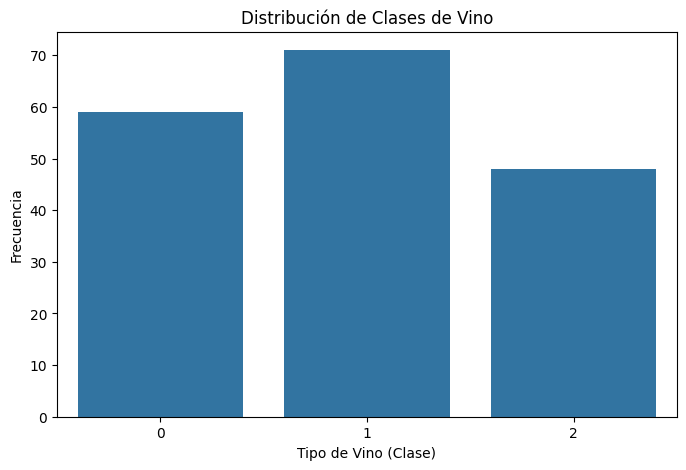

In [ ]:
# Información general
print("--- Información del Dataset ---")
print(f"Número de observaciones: {X.shape[0]}")
print(f"Número de variables: {X.shape[1]}")
print("\n--- Tipo de datos por variable ---")
print(X.dtypes)

# Distribución de la variable objetivo
print("\n--- Distribución de clases ---")
print(y.value_counts().sort_index())

# Visualización de la distribución
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title('Distribución de Clases de Vino')
plt.xlabel('Tipo de Vino (Clase)')
plt.ylabel('Frecuencia')
plt.show()

## 2. Preprocesamiento
El preprocesamiento es clave para asegurar que todas las variables contribuyan de forma equitativa al modelo. Aquí evaluamos la necesidad de escalado.

In [3]:
# Aunque GaussianNB no requiere estrictamente escalado, lo aplicamos para comparar
# y asegurar que variables con rangos grandes no dominen visualmente/analíticamente.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados correctamente utilizando StandardScaler.")

Datos escalados correctamente utilizando StandardScaler.


## 3. Entrenamiento del modelo
Dividimos el conjunto de datos en entrenamiento y prueba para evaluar la capacidad de generalización del modelo Naive Bayes.

In [4]:
# División de datos (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# Inicializar y entrenar el modelo Naive Bayes (Gaussian)
model = GaussianNB()
model.fit(X_train, y_train)

print(f"Tamaño del set de entrenamiento: {len(X_train)} muestras")
print(f"Tamaño del set de prueba: {len(X_test)} muestras")

Tamaño del set de entrenamiento: 142 muestras
Tamaño del set de prueba: 36 muestras


## 4. Evaluación
Analizamos el rendimiento del modelo mediante la matriz de confusión y métricas de precisión.

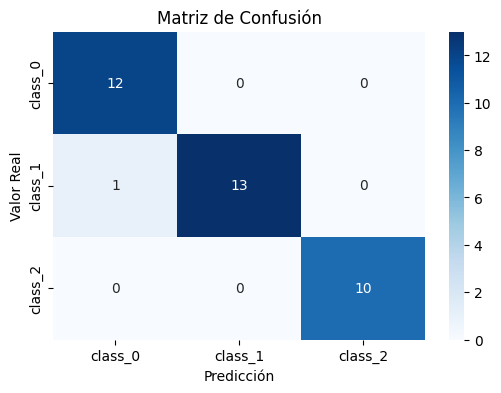


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

Accuracy Global: 0.9722


In [5]:
# Realizar predicciones
y_pred = model.predict(X_test)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Reporte de Clasificación y Accuracy
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=data.target_names))

print(f"Accuracy Global: {accuracy_score(y_test, y_pred):.4f}")

## 5. Conclusiones
Resumen del desempeño, limitaciones observadas y utilidad del modelo en un entorno real.

In [8]:
# Ver si hubo errores específicos
df_comparativa = pd.DataFrame({'Real': y_test, 'Predicho': y_pred})
errores = df_comparativa[df_comparativa['Real'] != df_comparativa['Predicho']]

if len(errores) == 0:
    print("El modelo clasificó perfectamente todas las muestras del set de test.")
else:
    print(f"El modelo cometió {len(errores)} errores.")
    print(errores)

El modelo cometió 1 errores.
    Real  Predicho
66     1         0
